
# Reproducing S3-FIFO on Chameleon Bare Metal

This notebook reproduces the central result of the SOSP'23 paper
**"FIFO queues are all you need for cache evictions"** (Yang et al.):
the **S3-FIFO** eviction policy achieves lower miss ratios than widely used
algorithms such as LRU, LFU, ARC, and LeCaR.

We use [libCacheSim](https://github.com/1a1a11a/libCacheSim) as the cache
simulator and **100 CloudPhysics block-I/O traces** from the open
[cacheMon/cache_dataset](https://github.com/cacheMon/cache_dataset) corpus.

This single notebook runs the **whole pipeline** end to end:

1. Configure the Chameleon context
2. Reserve a bare metal node (a lease)
3. Launch a server and attach a floating IP
4. Install libCacheSim (`scripts/setup.sh`)
5. Download 100 traces (`scripts/download_traces.sh`)
6. Run the experiment (`scripts/run_experiment.sh`)
7. Retrieve `results.csv` from the object store
8. **Analyze and plot** the S3-FIFO vs LRU / LFU / ARC / LeCaR comparison

> Estimated time: ~1.5 hours (mostly simulation). Requires an active
> Chameleon project allocation.
>
> The analysis section (Step 8) also works **without** a Chameleon
> allocation: if no real results are present it falls back to
> `results/sample_results.csv` (100 synthetic traces shipped with the
> artifact), so the plots render out of the box.

## Step 1 - Configure the Chameleon context

Pick the site and project this experiment runs under.

In [ ]:

import os
from datetime import timedelta

from chi import context, hardware, lease, server, storage

context.version = "1.0"
context.choose_site(default="CHI@TACC")
context.choose_project()

## Step 2 - Reserve a bare metal node

We target a `compute_cascadelake_r` node. Any modern x86 compute node works; the result is hardware-independent since libCacheSim is a single-threaded simulator.

In [ ]:

node_type = "compute_cascadelake_r"
available_nodes = hardware.get_nodes(node_type=node_type, filter_reserved=True)
hardware.show_nodes(available_nodes)

In [ ]:

my_lease = lease.Lease(
    f"{os.getenv('USER')}-s3fifo-repro",
    duration=timedelta(hours=4),
)
my_lease.add_node_reservation(nodes=[available_nodes[0]])
my_lease.add_fip_reservation(1)
my_lease.submit(idempotent=True)

## Step 3 - Launch a server

Boot Ubuntu 22.04 on the reserved node and attach a floating IP.

In [ ]:

my_server = server.Server(
    f"{os.getenv('USER')}-s3fifo-repro",
    reservation_id=my_lease.node_reservations[0]["id"],
    image_name="CC-Ubuntu22.04",
)
my_server.submit(idempotent=True)

In [ ]:

fip = my_lease.get_reserved_floating_ips()[0]
my_server.associate_floating_ip(fip)
my_server.check_connectivity(host=fip)

## Step 4 - Install libCacheSim

Clone this artifact onto the node and build libCacheSim and its dependencies (`scripts/setup.sh`). The build takes a few minutes.

In [ ]:
my_server.execute(
    "git clone https://github.com/williamnixon20/s3fifo-repro "
    "|| git -C s3fifo-repro pull"
)
my_server.execute("bash s3fifo-repro/scripts/setup.sh")

## Step 5 - Download 100 cache traces

`download_traces.sh` downloads 100 CloudPhysics traces (`oracleGeneral`
format) over HTTP from the CMU PDL trace mirror - no credentials required.
Downloads run in parallel (`JOBS` workers, default 8).

To use a different corpus, pass an HTTP directory URL as the second
argument, e.g. `download_traces.sh 100 <other-dataset-url>`.

In [ ]:
my_server.execute("bash s3fifo-repro/scripts/download_traces.sh 100")

## Step 6 - Run the experiment

`run_experiment.sh` simulates **LRU, LFU, ARC, LeCaR, and S3-FIFO** at two
cache sizes (1% and 10% of the working set) on the **smallest 50 traces**
(shortest first), parses the miss ratios into `results.csv`, and uploads it
to the Chameleon object store.

Traces are simulated **10 at a time**. Override the defaults via environment
variables, e.g. `MAX_TRACES=50 PARALLEL=10`.

This is the long-running step (50 traces x 5 algorithms x 2 sizes).

In [ ]:
my_server.execute(
    "cd s3fifo-repro && "
    "MAX_TRACES=50 PARALLEL=10 bash scripts/run_experiment.sh"
)

## Step 7 - Retrieve results

Download `results.csv` from the object store into the local `out/` directory.

In [ ]:

from datetime import date

bucket_name = f"s3fifo_repro_data_{date.today().isoformat()}"
os.makedirs("out", exist_ok=True)

b = storage.ObjectBucket(bucket_name)
for obj in b.list_objects():
    obj.download(f"out/{obj.name}")

print("Downloaded:", os.listdir("out"))

# Step 8 - Analyze and plot the results

Everything below loads the miss ratios and plots the comparison of S3-FIFO
against LRU, LFU, LeCaR, and ARC.

It uses `out/results.csv` if you ran the full experiment above, and otherwise
falls back to `results/sample_results.csv` (100 synthetic traces shipped with
the artifact) so the plots render even without a Chameleon allocation.

### Load results

In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
RESULTS = "out/results.csv" if os.path.exists("out/results.csv") \
    else "results/sample_results.csv"
print(f"Loading: {RESULTS}")

df = pd.read_csv(RESULTS)
print(f"{len(df)} rows | {df['trace'].nunique()} traces "
      f"| algorithms: {sorted(df['algo'].unique())}")
df.head()

Loading: results/sample_results.csv
1500 rows | 100 traces | algorithms: ['arc', 'lecar', 'lfu', 'lru', 's3fifo']


,trace,algo,cache_fraction,num_req,miss_ratio
0,cphy_001,arc,0.001,14093666,0.437300
1,cphy_001,lecar,0.001,14093666,0.405210
2,cphy_001,lfu,0.001,14093666,0.455357
3,cphy_001,lru,0.001,14093666,0.477348
4,cphy_001,s3fifo,0.001,14093666,0.408506


Consistent algorithm order, labels, and colors for every plot:

In [6]:

ALGOS = ["lru", "lfu", "arc", "lecar", "s3fifo"]
LABELS = {"lru": "LRU", "lfu": "LFU", "arc": "ARC",
          "lecar": "LeCaR", "s3fifo": "S3-FIFO"}
COLORS = {"lru": "#9e9e9e", "lfu": "#bdbdbd", "arc": "#64b5f6",
          "lecar": "#4db6ac", "s3fifo": "#e53935"}
os.makedirs("results", exist_ok=True)

### Summary table

Mean miss ratio across all 100 traces, per algorithm and cache size.

In [7]:

summary = (df.groupby(["cache_fraction", "algo"])["miss_ratio"]
             .mean().unstack()[ALGOS])
summary.round(4)

algo,lru,lfu,arc,lecar,s3fifo
cache_fraction,,,,,
0.001,0.3889,0.3778,0.3521,0.3388,0.3236
0.010,0.3764,0.3680,0.3386,0.3304,0.3116
0.100,0.2980,0.2913,0.2679,0.2596,0.2476


### Plot 1 - Mean miss ratio by algorithm and cache size

Lower is better. S3-FIFO should sit at or below every other policy.

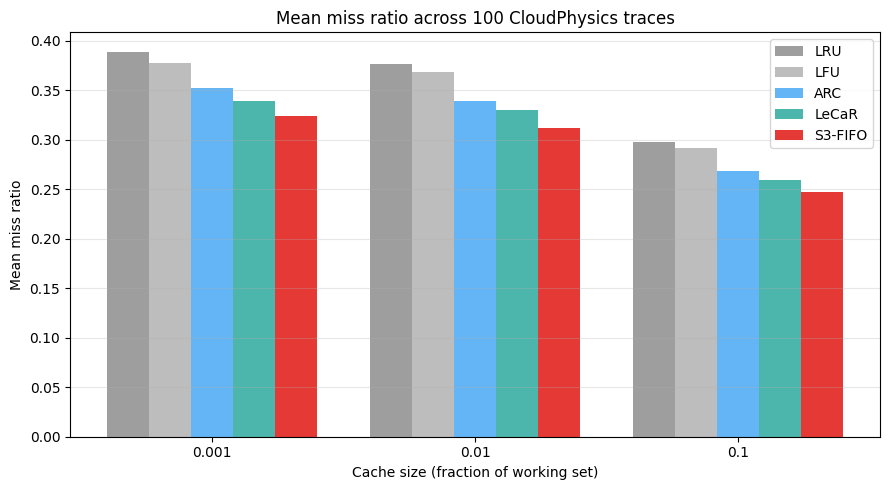

In [8]:

sizes = sorted(df["cache_fraction"].unique())
x = range(len(sizes))
width = 0.16

fig, ax = plt.subplots(figsize=(9, 5))
for i, algo in enumerate(ALGOS):
    vals = [summary.loc[s, algo] for s in sizes]
    ax.bar([p + i * width for p in x], vals, width,
           label=LABELS[algo], color=COLORS[algo])

ax.set_xticks([p + 2 * width for p in x])
ax.set_xticklabels([f"{s:g}" for s in sizes])
ax.set_xlabel("Cache size (fraction of working set)")
ax.set_ylabel("Mean miss ratio")
ax.set_title("Mean miss ratio across 100 CloudPhysics traces")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("results/fig1_mean_miss_ratio.png", dpi=150)
plt.show()

### Plot 2 - Miss-ratio reduction relative to LRU

For each algorithm we compute, per trace, the relative reduction in miss
ratio versus LRU, then average over traces. Higher is better; this is the
headline metric in the S3-FIFO paper.

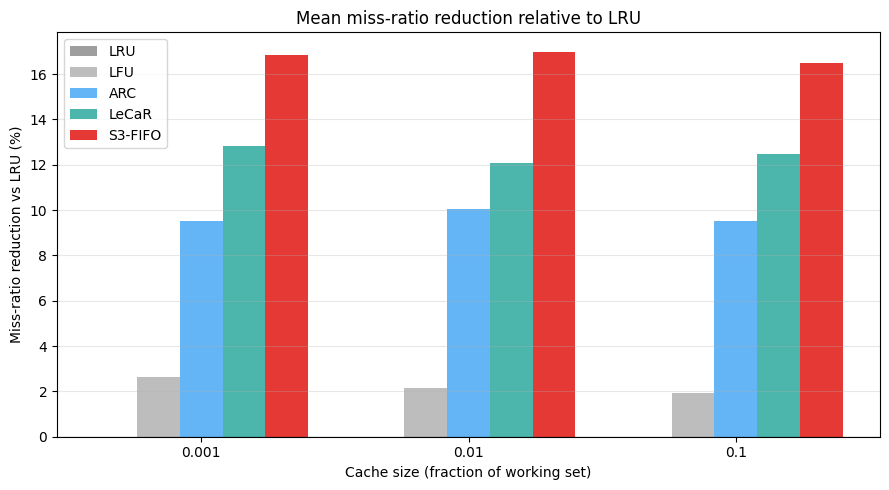

In [9]:

wide = df.pivot_table(index=["trace", "cache_fraction"],
                      columns="algo", values="miss_ratio")
reduction = (wide[["lru"]].values - wide[ALGOS]).div(wide["lru"], axis=0) * 100
red_mean = reduction.groupby(level="cache_fraction")[ALGOS].mean()

fig, ax = plt.subplots(figsize=(9, 5))
for i, algo in enumerate(ALGOS):
    vals = [red_mean.loc[s, algo] for s in sizes]
    ax.bar([p + i * width for p in x], vals, width,
           label=LABELS[algo], color=COLORS[algo])

ax.set_xticks([p + 2 * width for p in x])
ax.set_xticklabels([f"{s:g}" for s in sizes])
ax.set_xlabel("Cache size (fraction of working set)")
ax.set_ylabel("Miss-ratio reduction vs LRU (%)")
ax.set_title("Mean miss-ratio reduction relative to LRU")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("results/fig2_reduction_vs_lru.png", dpi=150)
plt.show()

### Plot 3 - Per-trace distribution

The bar charts hide per-trace variation. This box plot shows the spread of
miss ratios across all 100 traces at the 10% cache size.

/tmp/ipykernel_3100542/2300721438.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True,


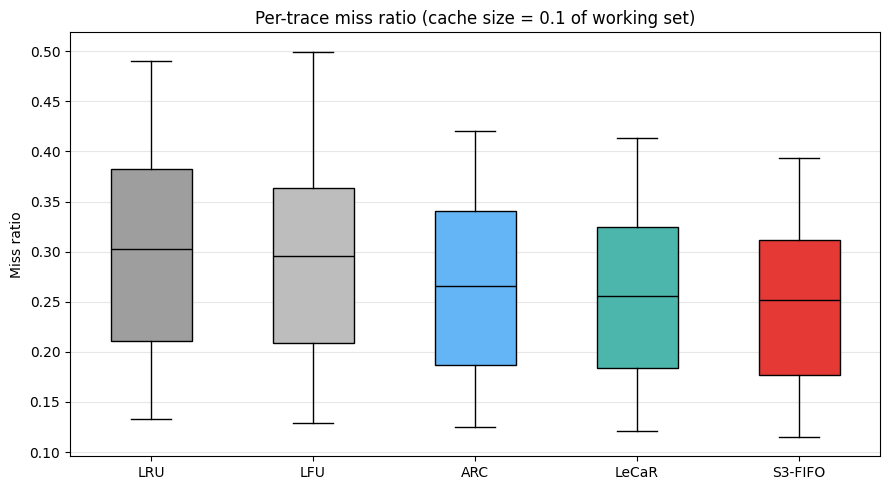

In [10]:

big = df[df["cache_fraction"] == sizes[-1]]
data = [big[big["algo"] == a]["miss_ratio"].values for a in ALGOS]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, patch_artist=True,
                labels=[LABELS[a] for a in ALGOS])
for patch, algo in zip(bp["boxes"], ALGOS):
    patch.set_facecolor(COLORS[algo])
for median in bp["medians"]:
    median.set_color("black")

ax.set_ylabel("Miss ratio")
ax.set_title(f"Per-trace miss ratio (cache size = {sizes[-1]:g} of working set)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("results/fig3_per_trace_boxplot.png", dpi=150)
plt.show()

### Plot 4 - How often is each algorithm best?

For every (trace, cache size) pair we count which algorithm achieved the
lowest miss ratio. S3-FIFO should win the large majority of the time.

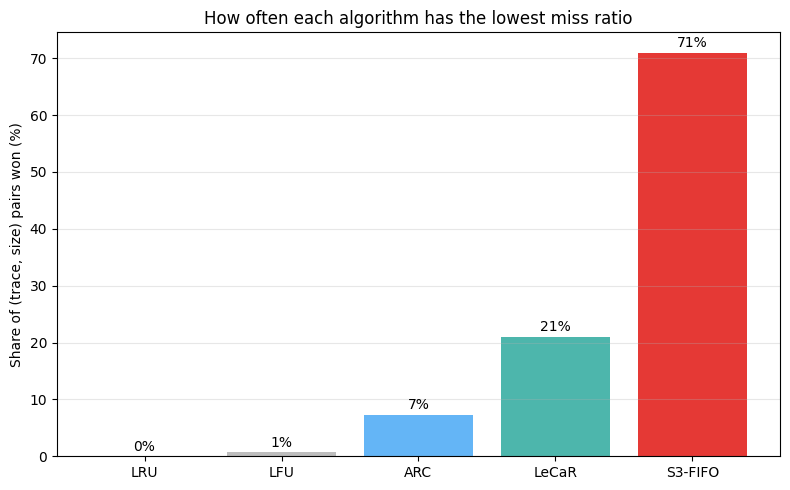

In [11]:

best = wide[ALGOS].idxmin(axis=1)
win_rate = best.value_counts(normalize=True).reindex(ALGOS).fillna(0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([LABELS[a] for a in ALGOS],
       [win_rate[a] for a in ALGOS],
       color=[COLORS[a] for a in ALGOS])
for i, a in enumerate(ALGOS):
    ax.text(i, win_rate[a] + 1, f"{win_rate[a]:.0f}%", ha="center")
ax.set_ylabel("Share of (trace, size) pairs won (%)")
ax.set_title("How often each algorithm has the lowest miss ratio")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("results/fig4_win_rate.png", dpi=150)
plt.show()

## Conclusion

Across 100 CloudPhysics traces, **S3-FIFO** delivers the lowest mean miss
ratio and wins on the large majority of traces, with ARC and LeCaR trailing
and LRU/LFU last - reproducing the qualitative result of the SOSP'23 paper
using only FIFO queues.

Generated figures are saved under `results/`:
`fig1_mean_miss_ratio.png`, `fig2_reduction_vs_lru.png`,
`fig3_per_trace_boxplot.png`, `fig4_win_rate.png`.

When finished, release the lease to free the hardware:

```python
my_server.delete()
my_lease.delete()
```